### Problem statement:
PeerLoanKart is an NBFC (non-banking financial company) that facilitates peer-to-peer loans. It connects people who need money (borrowers) with people who have money (investors). As an investor, you would want to invest in people who showed a profile of having a high probability of paying you back. Create a model that will help predict whether a borrower will repay the loan.

#### Installing imbalanced-learn library for SMOTE (Synthethic Minority Oversampling Technique):

As out dataset has class imbalance (Positive class has very less representation (counts) than Negative class), we will use SMOTE technique to synthetically increase instances of Positive class.

In [78]:
!pip install imbalanced-learn

#### 1) Importing Necessary Libraries:

In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, ConfusionMatrixDisplay, RocCurveDisplay

import warnings
warnings.filterwarnings('ignore')

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline # Using Pipeline from ImbLearn instead of sklearn as we want to fir preprocessing, SMOTE, model building all in one pipeline and skleanr pipeline doesn't support SMOTE.

#### 2) Loading Data:

In [2]:
df = pd.read_csv('loan_borowwer_data.csv')

In [3]:
df.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [4]:
df.shape

(9578, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
credit.policy,9578.0,0.804970,0.396245,0.000000,1.000000,1.000000,1.000000,1.000000e+00
int.rate,9578.0,0.122640,0.026847,0.060000,0.103900,0.122100,0.140700,2.164000e-01
installment,9578.0,319.089413,207.071301,15.670000,163.770000,268.950000,432.762500,9.401400e+02
log.annual.inc,9578.0,10.932117,0.614813,7.547502,10.558414,10.928884,11.291293,1.452835e+01
dti,9578.0,12.606679,6.883970,0.000000,7.212500,12.665000,17.950000,2.996000e+01
fico,9578.0,710.846314,37.970537,612.000000,682.000000,707.000000,737.000000,8.270000e+02
days.with.cr.line,9578.0,4560.767197,2496.930377,178.958333,2820.000000,4139.958333,5730.000000,1.763996e+04
revol.bal,9578.0,16913.963876,33756.189557,0.000000,3187.000000,8596.000000,18249.500000,1.207359e+06
revol.util,9578.0,46.799236,29.014417,0.000000,22.600000,46.300000,70.900000,1.190000e+02
inq.last.6mths,9578.0,1.577469,2.200245,0.000000,0.000000,1.000000,2.000000,3.300000e+01


In [7]:
df.dtypes

credit.policy          int64
purpose               object
int.rate             float64
installment          float64
log.annual.inc       float64
dti                  float64
fico                   int64
days.with.cr.line    float64
revol.bal              int64
revol.util           float64
inq.last.6mths         int64
delinq.2yrs            int64
pub.rec                int64
not.fully.paid         int64
dtype: object

- There are Numeric ane Categorical features in data.
- Data has no missing values.

#### 3) Data Cleaning and Transformations:

In [8]:
df.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


##### 1) credit.policy: 

In [9]:
df['credit.policy']

0       1
1       1
2       1
3       1
4       1
       ..
9573    0
9574    0
9575    0
9576    0
9577    0
Name: credit.policy, Length: 9578, dtype: int64

In [10]:
df['credit.policy'].value_counts()

credit.policy
1    7710
0    1868
Name: count, dtype: int64

- Credit policy is a Categorical feature which is already numerically encoded as 0 and 1.
- No transformations needed.

##### 2) purpose:

In [11]:
df['purpose']

0       debt_consolidation
1              credit_card
2       debt_consolidation
3       debt_consolidation
4              credit_card
               ...        
9573             all_other
9574             all_other
9575    debt_consolidation
9576      home_improvement
9577    debt_consolidation
Name: purpose, Length: 9578, dtype: object

In [12]:
df['purpose'].value_counts()

purpose
debt_consolidation    3957
all_other             2331
credit_card           1262
home_improvement       629
small_business         619
major_purchase         437
educational            343
Name: count, dtype: int64

- purpose is a Nominal Categorical Variable.
- Transformations: One Hot Encoding, Scaling.

In [13]:
purpose_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown= 'ignore')),
    ('scaler', StandardScaler(with_mean= False))
])

##### 3) int.rate:

In [14]:
df['int.rate']

0       0.1189
1       0.1071
2       0.1357
3       0.1008
4       0.1426
         ...  
9573    0.1461
9574    0.1253
9575    0.1071
9576    0.1600
9577    0.1392
Name: int.rate, Length: 9578, dtype: float64

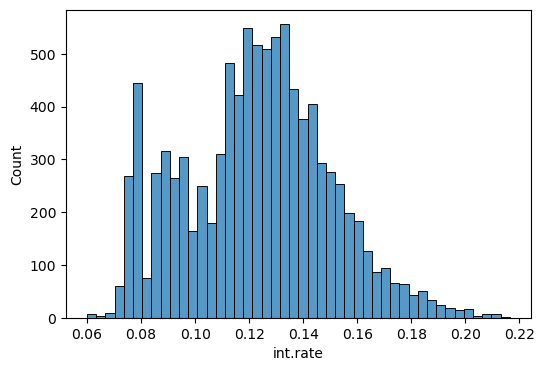

In [15]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'int.rate')
plt.show()

- int.rate is a Numerical and Continuous feature having distribution close to Normal.
- Ttansformations: Scaling.

In [16]:
intrate_pipeline = Pipeline([
    ('scaling', StandardScaler())
])

##### 4) installment:

In [17]:
df['installment']

0       829.10
1       228.22
2       366.86
3       162.34
4       102.92
         ...  
9573    344.76
9574    257.70
9575     97.81
9576    351.58
9577    853.43
Name: installment, Length: 9578, dtype: float64

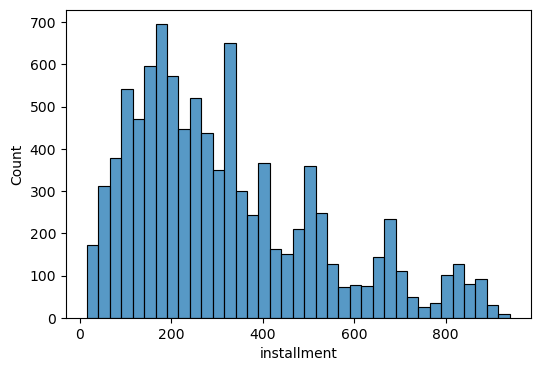

In [18]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'installment')
plt.show()

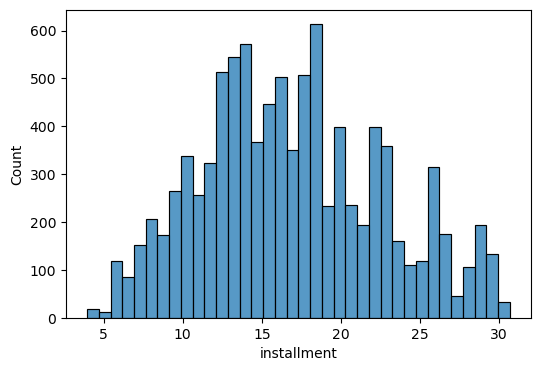

In [19]:
plt.figure(figsize= (6,4))
sns.histplot(data= df['installment'].apply(np.sqrt))
plt.show()

- installment is a Numeric and continuous feature with right tailed distribution.
- Transformation: Square Root Transformation, Scaling.

In [20]:
installment_pipeline = Pipeline([
    ('transformation', FunctionTransformer(np.sqrt)),
    ('scaler', StandardScaler())
])

##### 5) log.annual.inc:

In [21]:
df['log.annual.inc']

0       11.350407
1       11.082143
2       10.373491
3       11.350407
4       11.299732
          ...    
9573    12.180755
9574    11.141862
9575    10.596635
9576    10.819778
9577    11.264464
Name: log.annual.inc, Length: 9578, dtype: float64

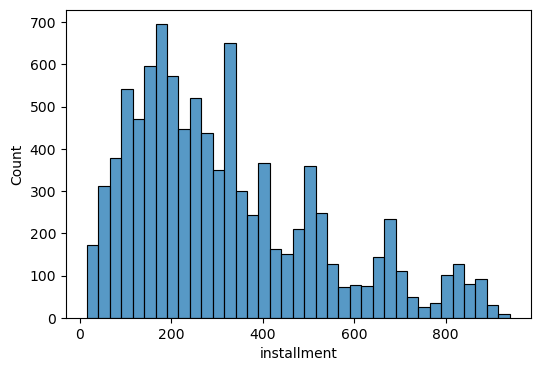

In [22]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'installment')
plt.show()

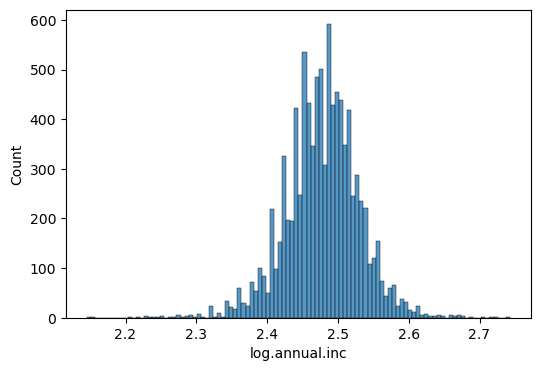

In [23]:
plt.figure(figsize= (6,4))
sns.histplot(data= df['log.annual.inc'].apply(np.log1p))
plt.show()

- log.annual.inc is a Numeric Continuous feature with a sligh right tailed distribution.
- Transformations: Log Transformation, Scaling.

In [24]:
annualinc_pipeline = Pipeline([
    ('transformation', FunctionTransformer(np.log1p)),
    ('scaler', StandardScaler())
])

##### 6) dti:

In [25]:
df['dti']

0       19.48
1       14.29
2       11.63
3        8.10
4       14.97
        ...  
9573    10.39
9574     0.21
9575    13.09
9576    19.18
9577    16.28
Name: dti, Length: 9578, dtype: float64

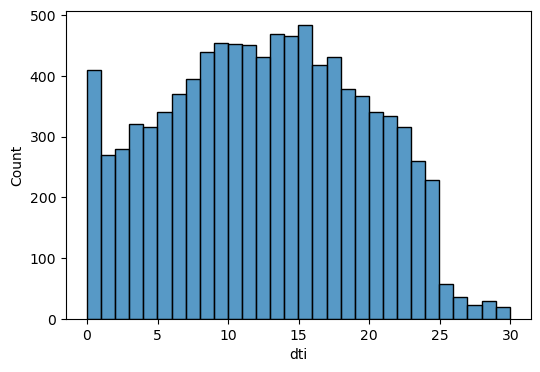

In [26]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'dti')
plt.show()

- dti is a Numeric Continuous feature having kind of normal distribution.
- Transformation: Scaling.

In [27]:
dti_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

##### 7) fico:

In [28]:
df['fico']

0       737
1       707
2       682
3       712
4       667
       ... 
9573    672
9574    722
9575    687
9576    692
9577    732
Name: fico, Length: 9578, dtype: int64

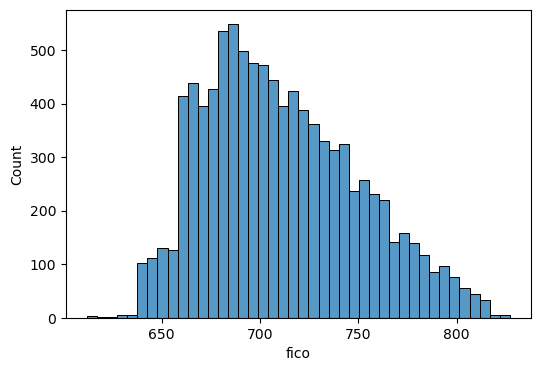

In [29]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'fico')
plt.show()

- fico is a Numeric Continuous feature.
- Transformation: Scaling.

In [30]:
fico_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

##### 8) days.with.cr.line:

In [31]:
df['days.with.cr.line']

0        5639.958333
1        2760.000000
2        4710.000000
3        2699.958333
4        4066.000000
            ...     
9573    10474.000000
9574     4380.000000
9575     3450.041667
9576     1800.000000
9577     4740.000000
Name: days.with.cr.line, Length: 9578, dtype: float64

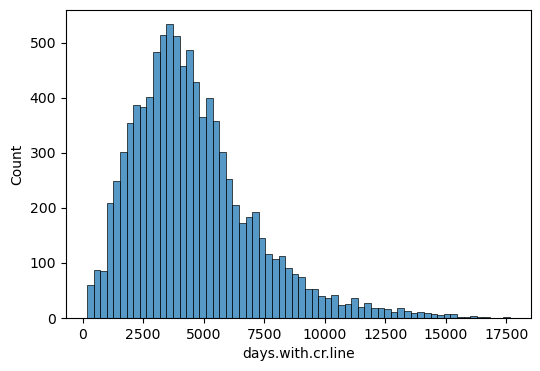

In [32]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'days.with.cr.line')
plt.show()

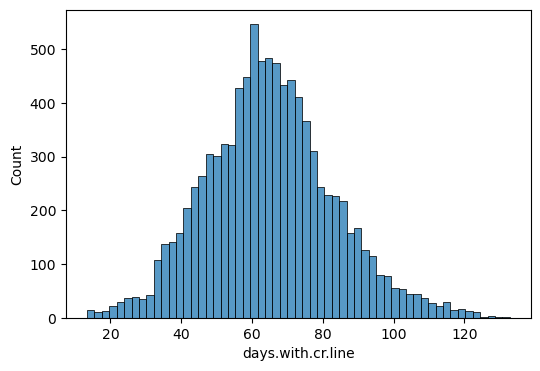

In [33]:
plt.figure(figsize= (6,4))
sns.histplot(data= df['days.with.cr.line'].apply(np.sqrt))
plt.show()

- days.with.cr.line is a Numeric Continuous feature with a right tailed distribution.
- Transformations: Square Root Transformation, Scaling.

In [34]:
dwcl_pipeline = Pipeline([
    ('transformation', FunctionTransformer(np.sqrt)),
    ('scaler', StandardScaler())
])

##### 9) revol.bal:

In [35]:
df['revol.bal']

0        28854
1        33623
2         3511
3        33667
4         4740
         ...  
9573    215372
9574       184
9575     10036
9576         0
9577     37879
Name: revol.bal, Length: 9578, dtype: int64

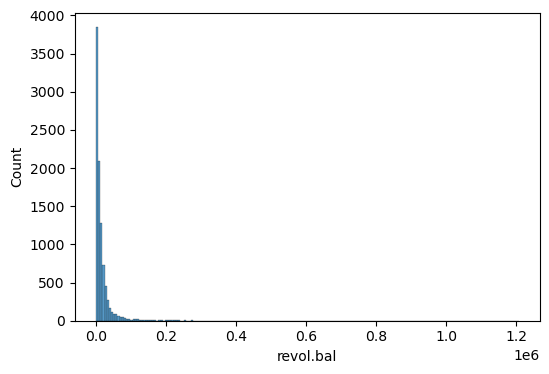

In [36]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'revol.bal')
plt.show()

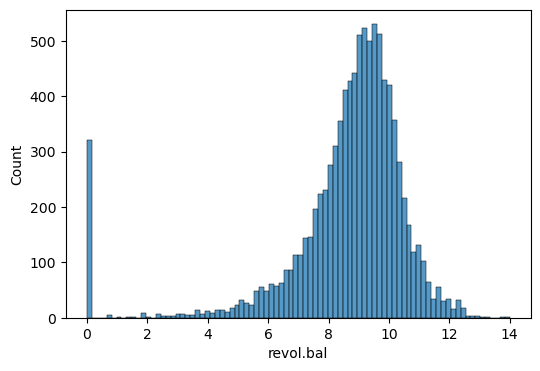

In [70]:
plt.figure(figsize= (6,4))
sns.histplot(data= df['revol.bal'].apply(np.log1p))
plt.show()

- revol.bal is a Numeric Continuous feature with long right tailed distribution.
- Transformations: Log Transformation, Scaling.

In [71]:
revolbal_pipeline = Pipeline([
    ('transformation', FunctionTransformer(np.log1p)),
    ('scaler', StandardScaler())
])

##### 10) revol.util:

In [39]:
df['revol.util']

0       52.1
1       76.7
2       25.6
3       73.2
4       39.5
        ... 
9573    82.1
9574     1.1
9575    82.9
9576     3.2
9577    57.0
Name: revol.util, Length: 9578, dtype: float64

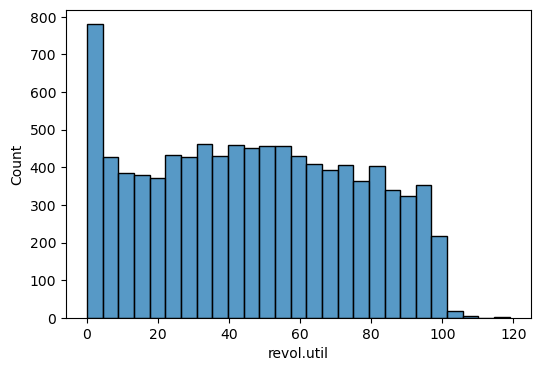

In [40]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'revol.util')
plt.show()

- revol.util is a Numeric Continuous feature.
- Transformation: Scaling.

In [41]:
revolutil_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

##### 11) inq.last.6mths:

In [42]:
df['inq.last.6mths']

0       0
1       0
2       1
3       1
4       0
       ..
9573    2
9574    5
9575    8
9576    5
9577    6
Name: inq.last.6mths, Length: 9578, dtype: int64

In [43]:
df['inq.last.6mths'].value_counts()

inq.last.6mths
0     3637
1     2462
2     1384
3      864
4      475
5      278
6      165
7      100
8       72
9       47
10      23
11      15
12      15
15       9
13       6
14       6
18       4
16       3
19       2
24       2
17       2
33       1
20       1
27       1
25       1
28       1
31       1
32       1
Name: count, dtype: int64

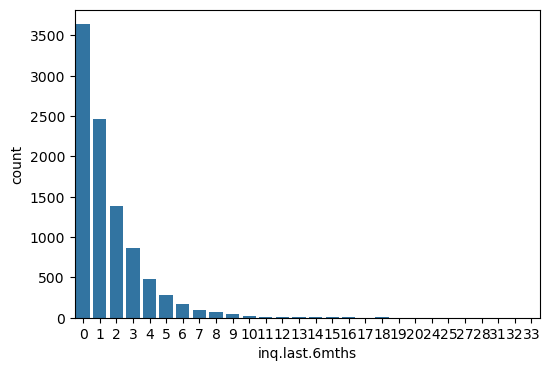

In [44]:
plt.figure(figsize= (6,4))
sns.countplot(data= df, x= 'inq.last.6mths')
plt.show()

- The data is highly skewed towards zero, which is common for count data (many people have 0 or 1 inquiries, and very few have 10+).
- Since the counts for high values (e.g., 10+) are very low, grouping them into bins can make the feature more robust and prevent models from overfitting to rare occurrences.

In [45]:
# Binning the 'inq.last.6mths' feature:

# Conditions:
conditions = [
    (df['inq.last.6mths'] == 0),
    (df['inq.last.6mths'] == 1),
    (df['inq.last.6mths'] == 2),
    (df['inq.last.6mths'] >= 3) & (df['inq.last.6mths'] <= 4),
    (df['inq.last.6mths'] >= 5)
]

# Bin Lables:
labels = [
    '0',
    '1',
    '2',
    '3-4',
    '5+'
]

df['inq.last.6mths_binned'] = np.select(conditions, labels, default='Missing')

In [46]:
df['inq.last.6mths_binned'].value_counts()

inq.last.6mths_binned
0      3637
1      2462
2      1384
3-4    1339
5+      756
Name: count, dtype: int64

In [47]:
# Dropping The Original Feature:

df.drop('inq.last.6mths', axis= 1, inplace= True)

- Newly created feature 'inq.last.6mths_binned' is Ordinal and Categorical in Nature.
- Transformations: Ordinal Encoding, Scaling.

In [48]:
inq_pipeline = Pipeline([
    ('encoder', OrdinalEncoder(categories= [['0', '1', '2', '3-4', '5+']])),
    ('scaler', StandardScaler())
])

##### 12) delinq.2yrs:

In [49]:
df['delinq.2yrs']

0       0
1       0
2       0
3       0
4       1
       ..
9573    0
9574    0
9575    0
9576    0
9577    0
Name: delinq.2yrs, Length: 9578, dtype: int64

In [50]:
df['delinq.2yrs'].value_counts()

delinq.2yrs
0     8458
1      832
2      192
3       65
4       19
5        6
6        2
13       1
7        1
8        1
11       1
Name: count, dtype: int64

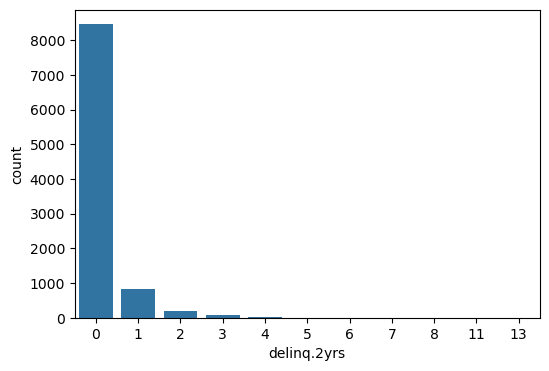

In [51]:
plt.figure(figsize= (6,4))
sns.countplot(data= df, x= 'delinq.2yrs')
plt.show()

- The data is highly skewed towards zero, which is common for count data (many people have 0 number of delinquencies in the last 2 years and very few more than 3).
- Since the counts for high values (e.g., 3+) are very low, grouping them into bins can make the feature more robust and prevent models from overfitting to rare occurrences.

In [52]:
# Binning the 'delinq.2yrs' feature:

# Conditions:
conditions = [
    (df['delinq.2yrs'] == 0),
    (df['delinq.2yrs'] == 1),
    (df['delinq.2yrs'] == 2),
    (df['delinq.2yrs'] >= 3)
]

# Bin Lables:
labels = [
    '0',
    '1',
    '2',
    '3+'
]

df['delinq.2yrs_binned'] = np.select(conditions, labels, default='Missing')

In [53]:
df['delinq.2yrs_binned'].value_counts()

delinq.2yrs_binned
0     8458
1      832
2      192
3+      96
Name: count, dtype: int64

In [54]:
# Dropping Original Feature:

df.drop('delinq.2yrs', axis= 1, inplace= True)

- Newly created feature 'delinq.2yrs_binned' is Ordinal and Categorical in Nature.
- Transformations: Ordinal Encoding, Scaling.

In [55]:
delinq_pipeline = Pipeline([
    ('encoder', OrdinalEncoder(categories= [['0', '1', '2', '3+']])),
    ('scaler', StandardScaler())
])

##### 13) pub.rec:

In [56]:
df['pub.rec']

0       0
1       0
2       0
3       0
4       0
       ..
9573    0
9574    0
9575    0
9576    0
9577    0
Name: pub.rec, Length: 9578, dtype: int64

In [57]:
df['pub.rec'].value_counts()

pub.rec
0    9019
1     533
2      19
3       5
4       1
5       1
Name: count, dtype: int64

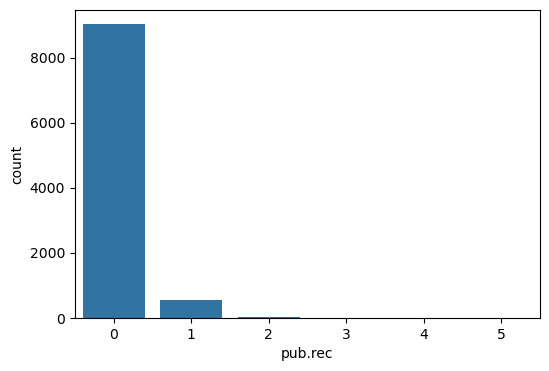

In [58]:
plt.figure(figsize= (6,4))
sns.countplot(data= df, x= 'pub.rec')
plt.show()

- The data is highly skewed towards zero, which is common for count data.
- Since the counts for high values (e.g., 2+) are very low, grouping them into bins can make the feature more robust and prevent models from overfitting to rare occurrences.

In [59]:
# Binning the 'pub.rec' feature:

# Conditions:
conditions = [
    (df['pub.rec'] == 0),
    (df['pub.rec'] == 1),
    (df['pub.rec'] >= 2)
]

# Bin Lables:
labels = [
    '0',
    '1',
    '2+'
]

df['pub.rec_binned'] = np.select(conditions, labels, default='Missing')

In [60]:
df['pub.rec_binned'].value_counts()

pub.rec_binned
0     9019
1      533
2+      26
Name: count, dtype: int64

In [61]:
# Dropping Original Feature:

df.drop('pub.rec', axis= 1, inplace= True)

- Newly created feature 'pub.rec_binned' is Ordinal and Categorical in Nature.
- Transformations: Ordinal Encoding, Scaling.

In [62]:
pubrec_pipeline = Pipeline([
    ('encoder', OrdinalEncoder(categories= [['0', '1', '2+']])),
    ('scaler', StandardScaler())
])

#### 4) Final Column Transformer:

In [72]:
preprocessor = ColumnTransformer([
    ('Purpose', purpose_pipeline, ['purpose']),
    ('Int_Rate', intrate_pipeline, ['int.rate']),
    ('Installment', installment_pipeline, ['installment']),
    ('Annual_Income', annualinc_pipeline, ['log.annual.inc']),
    ('DTI', dti_pipeline, ['dti']),
    ('FICO', fico_pipeline, ['fico']),
    ('Cr_Line_Days', dwcl_pipeline, ['days.with.cr.line']),
    ('Revol_Bal', revolbal_pipeline, ['revol.bal']),
    ('Revol_Util', revolutil_pipeline, ['revol.util']),
    ('Inquiry', inq_pipeline, ['inq.last.6mths_binned']),
    ('Delinq', delinq_pipeline, ['delinq.2yrs_binned']),
    ('Pub_Rec', pubrec_pipeline, ['pub.rec_binned'])
],
                                remainder= 'passthrough')

#### 5) Train Test Split:

In [80]:
X = df.drop('not.fully.paid', axis= 1) #Features
y = df['not.fully.paid'] #Target

In [81]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

In [82]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(7662, 13)
(1916, 13)
(7662,)
(1916,)


#### 6) Model Building and Evalutaion:

In [86]:
full_pipeline = ImbPipeline(steps= [
    ('Preprocessing', preprocessor),
    ('Over_Sampling', SMOTE()),
    ('Model', RandomForestClassifier())
])

param_dict = {'Over_Sampling__sampling_strategy': [0.5, 0.75, 'minority'], # For SMOTE() sampling strategy
             'Model__n_estimators': [5, 10, 25, 50, 100, 200, 500],
             'Model__criterion': ['gini', 'entropy'],
             'Model__max_depth': [2, 5, 10, 25, 50, None],
             'Model__bootstrap': [True, False],
             'Model__oob_score': [True, False]
}

grid_model = GridSearchCV(estimator= full_pipeline,
                         param_grid= param_dict,
                         scoring= 'roc_auc', # better for imbalanced data evaluation
                         cv= 5,
                         n_jobs= -1 # Use all available processors
                         )

In [ ]:
# Fitting the Grid Model:

grid_model.fit(X_train, y_train)